# 04 — Does RSI *divergence* have an edge? (15m, 2024 = train)

The original question of the line. nb03 showed bare RSI level is just a (worse) proxy for the `dump` magnitude edge. **Divergence is a different construct:** it's not "RSI is low", it's "price made a new extreme but RSI *did not confirm it*" — momentum quietly weakening. We test whether that disagreement predicts a reversal.

### Setup (lookahead-free)
- Swing pivots via `pivots(close, k)` — a pivot at bar `i` is only confirmed at `i+k`. **We enter at `i2+k`** (the moment the second swing is confirmed), never at the pivot itself. This is the discipline that the pump/levels lines died without.
- **Regular bullish** = price Lower-Low + RSI Higher-Low → **LONG**. **Regular bearish** = price Higher-High + RSI Lower-High → **SHORT**.
- 15m, **2024 only** (2025 sealed for OOS), pooled across the 165-symbol universe, forward return vs unconditional baseline, 0.15% cost.

### The control that decides it (mirror of nb03)
Hold the **price pattern fixed** and split by what RSI did. Among all confirmed **Higher-High** swings: those where RSI *diverged* (lower high) vs *confirmed* (higher high). Among all **Lower-Low** swings: RSI *diverged* (higher low) vs *confirmed* (lower low). If divergence carries real information, the diverged group reverses more than the confirmed group at the **same** price pattern. If they're equal, the signal is the swing/magnitude, not the RSI disagreement.

**Prediction:** bullish-LONG is positive (it sits at lows after drops = magnitude) but ≈ the Lower-Low control (RSI adds little); bearish-SHORT is weak/negative like every short in this line.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import numpy as np

TF = "15min"
Y0, Y1 = "2024-01-01", "2025-01-01"            # 2024 ONLY (2025 = OOS)
RSI_N, K, MIN_GAP, MAX_GAP, COST = 14, 6, 5, 72, 0.0015
HS = [4, 8, 16, 32, 48]                          # forward horizons in 15m bars (1h .. 12h)

uni = [s for s in list_symbols() if coverage(s)[0] <= "2024-01" and coverage(s)[1] >= "2024-12"]
print(f"universe {len(uni)} | {TF} {Y0}..{Y1} | RSI({RSI_N}) pivots k={K} gap[{MIN_GAP},{MAX_GAP}] | enter at i2+k")

universe 165 | 15min 2024-01-01..2025-01-01 | RSI(14) pivots k=6 gap[5,72] | enter at i2+k


In [2]:
# groups: bear_div / bear_conf (Higher-High, SHORT) and bull_div / bull_conf (Lower-Low, LONG).
# 'div' = RSI failed to confirm the price extreme; 'conf' = RSI confirmed it.
GROUPS = ["bear_div", "bear_conf", "bull_div", "bull_conf"]
ret = {g: {h: [] for h in HS} for g in GROUPS}
base_sum = {h: 0.0 for h in HS}; base_n = {h: 0 for h in HS}

for j, s in enumerate(uni):
    try:
        d = ohlcv(s, Y0, Y1, TF)
    except Exception:
        continue
    c = d["close"]; cv = c.to_numpy()
    if len(cv) < 500:
        continue
    r = rsi(c, RSI_N).to_numpy()
    H = d["high"].to_numpy(); L = d["low"].to_numpy()
    hi, lo = pivots(c, K)
    n = len(cv)
    for h in HS:
        fr = cv[h:] / cv[:-h] - 1.0
        base_sum[h] += fr.sum(); base_n[h] += len(fr)

    def fwd(entry, h):
        return cv[entry + h] / cv[entry] - 1.0

    for a, b in zip(hi[:-1], hi[1:]):                 # Higher-High swings -> SHORT view
        if not (MIN_GAP <= b - a <= MAX_GAP and H[b] > H[a]):
            continue
        entry = b + K
        g = "bear_div" if r[b] < r[a] else "bear_conf"
        for h in HS:
            if entry + h < n:
                ret[g][h].append(fwd(entry, h))
    for a, b in zip(lo[:-1], lo[1:]):                 # Lower-Low swings -> LONG view
        if not (MIN_GAP <= b - a <= MAX_GAP and L[b] < L[a]):
            continue
        entry = b + K
        g = "bull_div" if r[b] > r[a] else "bull_conf"
        for h in HS:
            if entry + h < n:
                ret[g][h].append(fwd(entry, h))
    if (j + 1) % 40 == 0:
        print(f"  {j+1}/{len(uni)} done")

base = {h: base_sum[h] / base_n[h] for h in HS}
for g in GROUPS:
    print(f"{g:11s} events: {len(ret[g][HS[0]]):,}")

  40/165 done


  80/165 done


  120/165 done


  160/165 done


bear_div    events: 29,492
bear_conf   events: 107,853
bull_div    events: 29,425
bull_conf   events: 110,316


## Read-out: divergence vs confirmation vs baseline

Directional PnL (LONG for bullish/Lower-Low, SHORT=−fwd for bearish/Higher-High), net after 0.15% cost. The decisive columns are **div vs conf** at the *same* price pattern — that gap is the pure RSI-divergence contribution.

In [3]:
def stats(vals, sign, base_h):
    a = np.asarray(vals) * sign
    b = base_h * sign
    return dict(n=len(a), mean=round(a.mean()*100, 3), median=round(np.median(a)*100, 3),
                win=round((a > 0).mean()*100, 1), m_std=round(a.mean()/a.std(), 4),
                net_edge=round((a.mean()-b-COST)*100, 3))

for side, gdiv, gconf, sign in [("BEARISH (Higher-High -> SHORT)", "bear_div", "bear_conf", -1.0),
                                 ("BULLISH (Lower-Low -> LONG)", "bull_div", "bull_conf", +1.0)]:
    print(f"\n=== {side} ===")
    rows = []
    for h in HS:
        sd = stats(ret[gdiv][h], sign, base[h]); sc = stats(ret[gconf][h], sign, base[h])
        rows.append(dict(h=h, n_div=sd["n"], div_mean=sd["mean"], div_net=sd["net_edge"], div_mstd=sd["m_std"],
                         n_conf=sc["n"], conf_mean=sc["mean"], conf_net=sc["net_edge"],
                         div_minus_conf=round(sd["mean"]-sc["mean"], 3)))
    print(pd.DataFrame(rows).set_index("h").to_string())


=== BEARISH (Higher-High -> SHORT) ===
    n_div  div_mean  div_net  div_mstd  n_conf  conf_mean  conf_net  div_minus_conf
h                                                                                  
4   29492    -0.013   -0.155   -0.0100  107853     -0.022    -0.164           0.009
8   29491    -0.029   -0.164   -0.0159  107851     -0.015    -0.149          -0.014
16  29491    -0.077   -0.196   -0.0285  107850      0.001    -0.118          -0.078
32  29475    -0.154   -0.242   -0.0434  107834      0.005    -0.084          -0.159
48  29431    -0.189   -0.248   -0.0434  107740     -0.027    -0.086          -0.162

=== BULLISH (Lower-Low -> LONG) ===
    n_div  div_mean  div_net  div_mstd  n_conf  conf_mean  conf_net  div_minus_conf
h                                                                                  
4   29425     0.023   -0.134    0.0205  110316     -0.009    -0.166           0.032
8   29422     0.075   -0.090    0.0471  110304      0.027    -0.138           0.048

[saved] notebooks\rsi\_out\04_divergence_edge.png


WindowsPath('C:/projects/researchlab/notebooks/rsi/_out/04_divergence_edge.png')

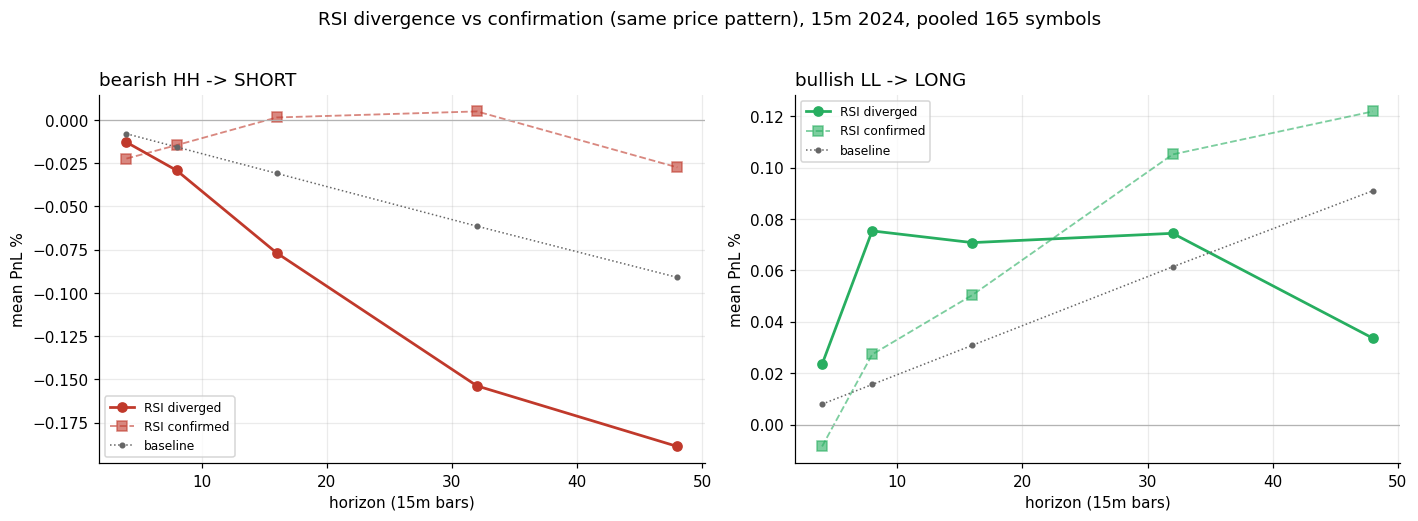

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (side, gdiv, gconf, sign, col) in zip(axes, [
        ("bearish HH -> SHORT", "bear_div", "bear_conf", -1.0, "#c0392b"),
        ("bullish LL -> LONG", "bull_div", "bull_conf", +1.0, "#27ae60")]):
    div = [np.asarray(ret[gdiv][h]).mean()*sign*100 for h in HS]
    conf = [np.asarray(ret[gconf][h]).mean()*sign*100 for h in HS]
    bl = [base[h]*sign*100 for h in HS]
    ax.plot(HS, div, "o-", color=col, lw=1.8, label="RSI diverged")
    ax.plot(HS, conf, "s--", color=col, lw=1.2, alpha=0.6, label="RSI confirmed")
    ax.plot(HS, bl, ".:", color="0.4", lw=1.0, label="baseline")
    ax.axhline(0, color="0.7", lw=0.8)
    ax.set_xlabel("horizon (15m bars)"); ax.set_ylabel("mean PnL %")
    ax.set_title(side, loc="left"); ax.legend(fontsize=8)
fig.suptitle(f"RSI divergence vs confirmation (same price pattern), 15m 2024, pooled {len(uni)} symbols", y=1.02)
show("04_divergence_edge")

## Verdict & caveats

**Divergence is not tradeable on 15m/2024 — bearish is an anti-signal, bullish is a sub-cost whisper.**

- **BEARISH (Higher-High → SHORT) is refuted, and worse than refuted.** Shorting a bearish divergence loses progressively (−0.19% @12h) and **underperforms shorting a non-divergent higher-high** (`div − conf` = −0.16% @12h). So \"RSI made a lower high → top is near\" is *anti*-predictive here: after a bearish divergence price keeps rising *more* than after a confirming higher-high. Consistent with the whole line — the short side is dead on up-drifting alts, and divergence makes it deader.

- **BULLISH (Lower-Low → LONG) carries a faint, direction-consistent whisper — but it's sub-cost.** At short horizons (1–2h) the diverged group beats its matched control: `div − conf` = +0.03% @1h, **+0.05% @2h**, +0.02% @4h, and beats baseline. That's exactly what theory predicts (a shallower momentum low → a quicker small bounce). **But in absolute terms every bullish-div net edge is negative after 0.15% cost** (best = −0.090% @2h). And at 8–12h the *confirmed* lower-low overtakes it (+0.122% vs +0.034%) — a confirmed LL = a deeper capitulation = a bigger eventual bounce = **magnitude/`dump` again**.

**So:** the only real RSI-specific information is a small bullish-divergence lift over its control at 1–2h — genuine but economically dead (sub-cost), and dominated by plain magnitude at the horizons where the bounce actually pays. This is the same shape the `levels` line kept hitting: a consistent real>control whisper (~3–5 bp) that never reaches tradeable.

**Caveats:** one parameter set (`k=6`, gap[5,72], RSI=14); 15m only — **divergence is classically a higher-TF tool, and nb01 showed 1h/4h divergences look cleaner**, so a 1h/4h re-test is the one fair shot left before closing; overlapping windows (effective n < shown); 2024 only; no quality filter (pivot in OB/OS zone, slope steepness). 2025 stays sealed.